# TerraVista — Territorial-Risk Model Training

**Author:** Gabriel Mule — RM 560586  
**Module:** Machine Learning (hybrid data: synthetic core + real-data bridge)

This notebook documents the full ML workflow for the TerraVista territorial-risk
classifier that powers the `/api/predict` backend endpoint:

1. **Generate** a synthetic, reproducible dataset (`generator.py`).
2. **Explore** the synthetic data (distributions, correlations, class balance).
3. **Bridge to reality**: validate the generator against three real datasets —
   UCI Forest Fires (fire meteorology), Kaggle Crop Recommendation (agronomy),
   and NASA FIRMS (live satellite fires).
4. **Train** a `RandomForestClassifier` and evaluate it (recall-focused on the
   `CRITICAL` class — the costliest miss).
5. **Interpret** the model via feature importances.
6. **Persist** the model bundle to `models/terra_risk.joblib`.

> The MVP trains on the **synthetic** dataset for full reproducibility and
> independence; the real-data bridge provides professional credibility and
> calibration evidence.

## 0. Setup

We import from the sibling module `generator.py` so the notebook and the CLI
share a single source of truth (no duplicated logic).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the parent `ml/` package importable from `ml/notebooks/`.
ML_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ML_DIR))

from generator import (
    CLASS_NAMES,
    FEATURE_COLUMNS,
    TARGET_COLUMN,
    generate,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print("ML_DIR:", ML_DIR)
print("Features:", FEATURE_COLUMNS)

ML_DIR: /Users/gab/Documents/CodePlay/2TIAOR-global-solution-2/ml
Features: ['air_temperature', 'air_humidity', 'soil_moisture', 'solar_radiation', 'ndvi', 'days_since_rain', 'wind_speed']


## 1. Generate the synthetic dataset

Fixed seed (`42`) → identical dataset on every run. The generator intentionally
produces a **~50/35/15** class imbalance, mirroring real triage scenarios where
most parcels are healthy and few are critical.

In [2]:
df = generate(n_samples=5000, seed=42)
print(df.shape)
df.head()

(5000, 8)


,air_temperature,air_humidity,soil_moisture,solar_radiation,ndvi,days_since_rain,wind_speed,risk_class
0,27.8,55.4,40.8,687.0,0.322,7.0,12.6,0
1,19.8,54.6,52.4,693.0,0.780,7.0,3.2,0
2,30.5,47.5,14.4,655.0,0.610,17.0,32.5,1
3,31.6,67.7,33.4,599.0,0.512,2.0,19.9,1
4,14.3,64.2,51.3,594.0,0.575,21.0,19.0,0


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
air_temperature,5000.0,25.880680,5.997482,4.10,21.800,26.000,29.80000,46.70
air_humidity,5000.0,59.912100,17.948714,8.00,48.100,59.600,72.10000,100.00
soil_moisture,5000.0,37.931640,15.798725,3.00,27.100,37.500,48.60000,95.00
solar_radiation,5000.0,529.124400,180.350659,50.00,405.000,528.000,651.00000,1096.00
ndvi,5000.0,0.621448,0.173094,0.02,0.505,0.624,0.74125,0.95
days_since_rain,5000.0,8.008200,5.771065,0.00,4.000,7.000,11.00000,50.00
wind_speed,5000.0,11.962660,8.483199,0.00,5.700,10.000,16.20000,70.00
risk_class,5000.0,0.650000,0.726365,0.00,0.000,0.500,1.00000,2.00


## 2. Exploratory Data Analysis (synthetic)

### 2.1 Class balance

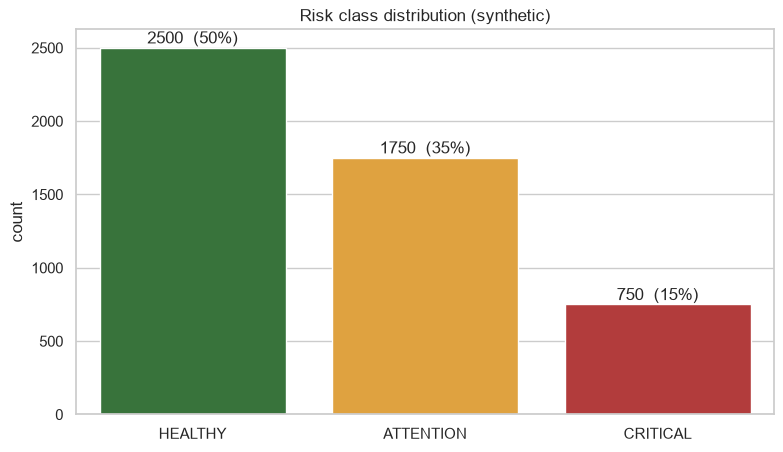

In [4]:
counts = df[TARGET_COLUMN].value_counts().sort_index()
labels = [CLASS_NAMES[i] for i in counts.index]

ax = sns.barplot(x=labels, y=counts.values, hue=labels, legend=False,
                 palette=["#2e7d32", "#f9a825", "#c62828"])
ax.set_title("Risk class distribution (synthetic)")
ax.set_ylabel("count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, f"{v}  ({v/len(df):.0%})", ha="center")
plt.show()

### 2.2 Feature distributions by risk class

We expect the physically-motivated drivers to separate the classes: CRITICAL
parcels should show **lower soil moisture**, **lower NDVI**, **higher
temperature** and **more dry days**.

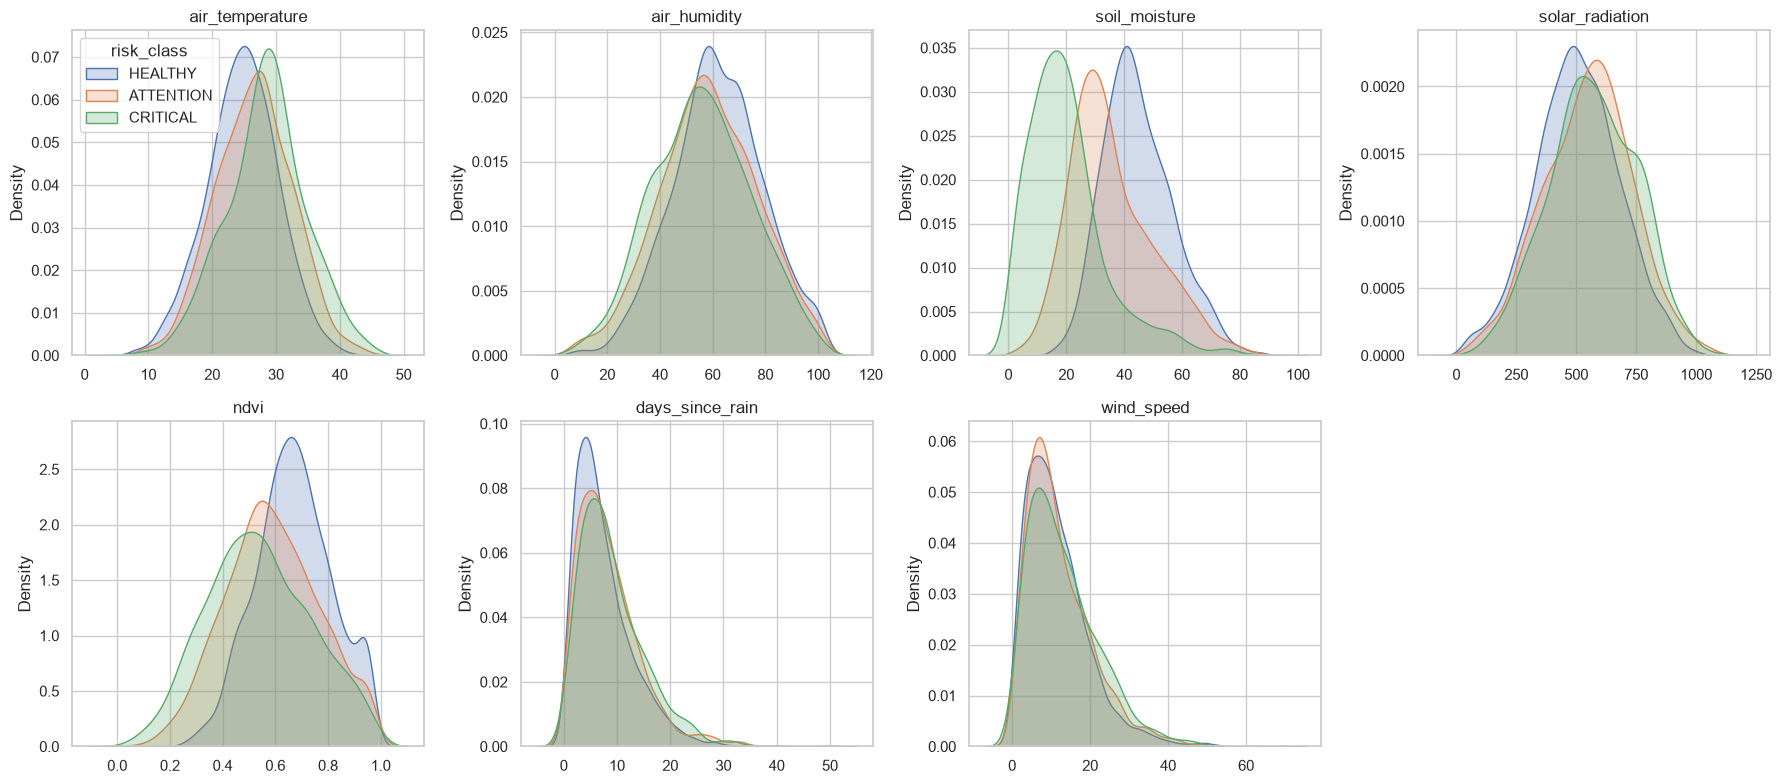

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), FEATURE_COLUMNS):
    for cls in sorted(CLASS_NAMES):
        sns.kdeplot(
            df.loc[df[TARGET_COLUMN] == cls, col],
            ax=ax,
            label=CLASS_NAMES[cls],
            fill=True,
            alpha=0.25,
        )
    ax.set_title(col)
    ax.set_xlabel("")
axes.ravel()[-1].axis("off")
axes.ravel()[0].legend(title="risk_class")
plt.tight_layout()
plt.show()

### 2.3 Correlation matrix (synthetic)

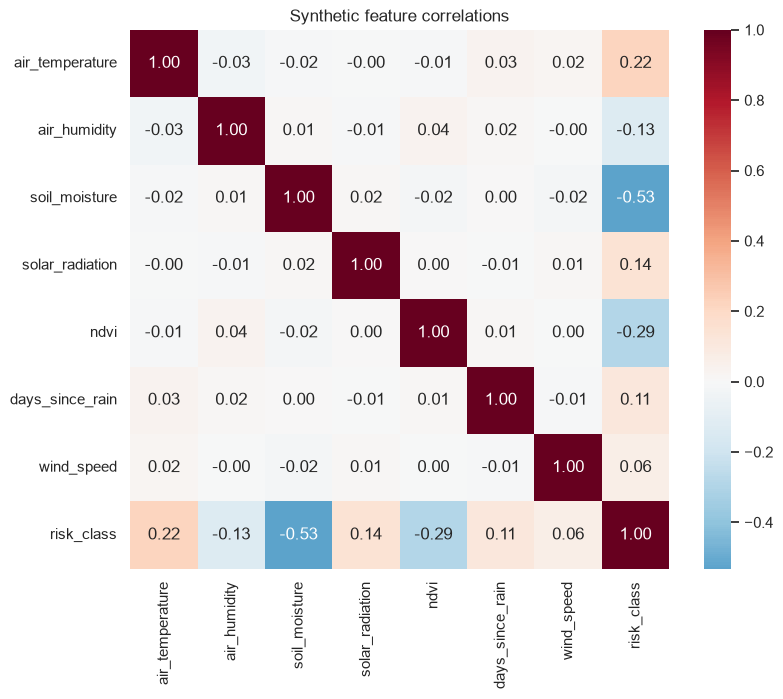

In [6]:
corr = df[FEATURE_COLUMNS + [TARGET_COLUMN]].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Synthetic feature correlations")
plt.show()

## 3. Reality bridge — UCI Forest Fires

To show the synthetic generator is **not arbitrary**, we compare its
meteorological correlations against the real *UCI Forest Fires* dataset
(Montesinho park, Portugal). Run `python real_data/download.py uci` first
(no login needed).

Shared/analogous features:

| TerraVista | UCI | meaning |
|---|---|---|
| `air_temperature` | `temp` | air temperature (°C) |
| `air_humidity` | `RH` | relative humidity (%) |
| `wind_speed` | `wind` | wind speed |
| `days_since_rain` | `rain` (inverse) | dryness proxy |
| `risk_class` | `area` (burned) | fire severity / risk |

In [7]:
uci_path = ML_DIR / "real_data" / "forestfires.csv"
if uci_path.exists():
    uci = pd.read_csv(uci_path)
    print("UCI Forest Fires:", uci.shape)
    display(uci.head())
else:
    uci = None
    print("UCI dataset not found. Run: python real_data/download.py uci")

UCI Forest Fires: (517, 13)


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


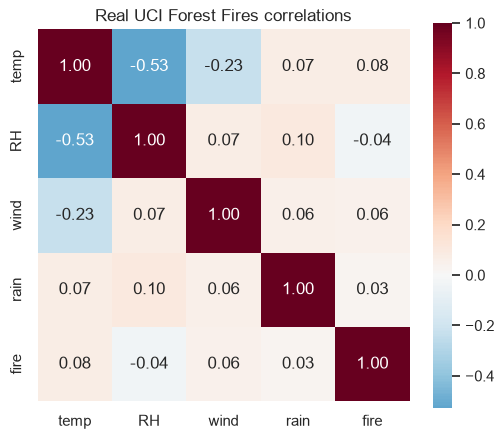

In [8]:
if uci is not None:
    # A binary 'fire occurred' target: burned area > 0.
    uci = uci.copy()
    uci["fire"] = (uci["area"] > 0).astype(int)
    uci_cols = ["temp", "RH", "wind", "rain", "fire"]
    uci_corr = uci[uci_cols].corr()
    plt.figure(figsize=(6, 5))
    sns.heatmap(uci_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
    plt.title("Real UCI Forest Fires correlations")
    plt.show()

### 3.1 Directional agreement check

We don't expect identical magnitudes (different regions, units, target
definitions), but the **sign/direction** of the relationships should agree —
that's what validates our coefficient choices:

- Higher **temperature** → higher risk (positive in both).
- Higher **humidity** → lower risk (negative in both).
- More **rain / fewer dry days** → lower risk.

In [9]:
if uci is not None:
    syn_corr = df[["air_temperature", "air_humidity", "wind_speed",
                   "days_since_rain", TARGET_COLUMN]].corr()[TARGET_COLUMN]
    bridge = pd.DataFrame({
        "driver": ["temperature", "humidity", "wind", "dryness"],
        "synthetic_vs_risk": [
            syn_corr["air_temperature"],
            syn_corr["air_humidity"],
            syn_corr["wind_speed"],
            syn_corr["days_since_rain"],
        ],
        "uci_vs_fire": [
            uci_corr.loc["temp", "fire"],
            uci_corr.loc["RH", "fire"],
            uci_corr.loc["wind", "fire"],
            -uci_corr.loc["rain", "fire"],  # invert: rain is the inverse of dryness
        ],
    })
    bridge["sign_agrees"] = (
        np.sign(bridge["synthetic_vs_risk"]) == np.sign(bridge["uci_vs_fire"])
    )
    display(bridge)
    print("Directional agreement:",
          f"{bridge['sign_agrees'].mean():.0%} of drivers")

,driver,synthetic_vs_risk,uci_vs_fire,sign_agrees
0,temperature,0.224002,0.076047,True
1,humidity,-0.132200,-0.035587,True
2,wind,0.063690,0.055702,True
3,dryness,0.110585,-0.025550,False


Directional agreement: 75% of drivers


### 3.2 Agronomic bridge — Kaggle Crop Recommendation

The fire bridge (UCI) validates the **disaster** side. To validate the
**agricultural** side, we use the real *Kaggle Crop Recommendation* dataset
(~2,200 rows: soil N/P/K, temperature, humidity, pH, rainfall → crop). Run
`python real_data/download.py kaggle` first.

We check that the agro feature ranges overlap our generator's assumptions:
viable crops cluster in warm, humid, rain-fed conditions — echoing how
`air_humidity` and water availability lower risk in our model.

In [10]:
crop_path = ML_DIR / "real_data" / "kaggle_crop" / "Crop_recommendation.csv"
if crop_path.exists():
    crop = pd.read_csv(crop_path)
    print("Kaggle Crop Recommendation:", crop.shape)
    print("crops:", crop["label"].nunique(), "|",
          ", ".join(sorted(crop["label"].unique())[:8]), "...")
    display(crop.head())
else:
    crop = None
    print("Kaggle dataset not found. Run: python real_data/download.py kaggle")

Kaggle Crop Recommendation: (2200, 8)
crops: 22 | apple, banana, blackgram, chickpea, coconut, coffee, cotton, grapes ...


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


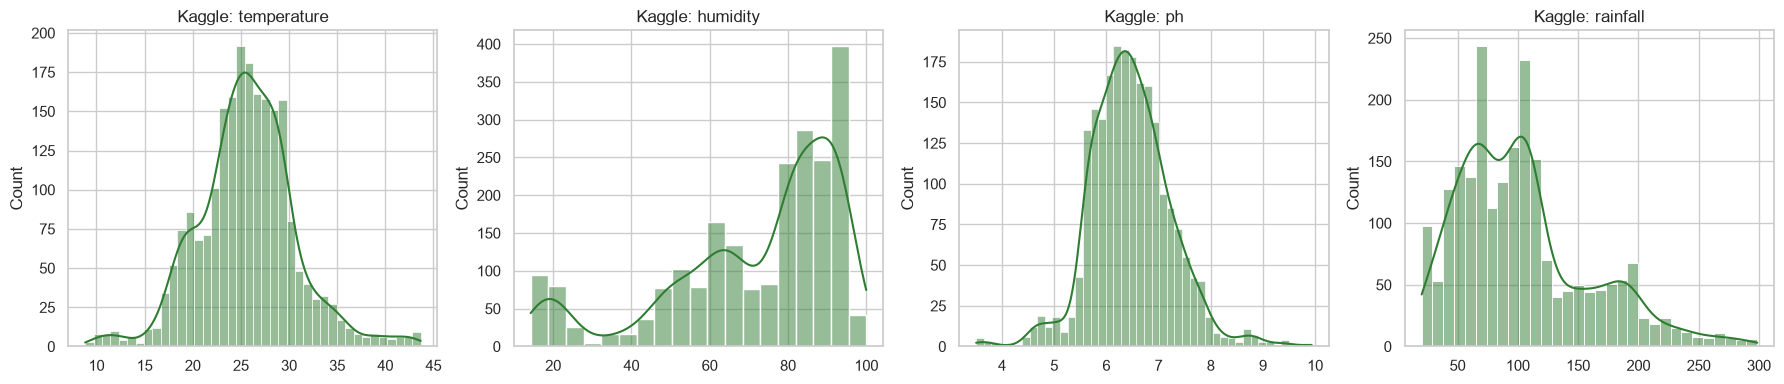

,mean,min,max
temperature,25.616244,8.825675,43.675493
humidity,71.481779,14.258040,99.981876
ph,6.469480,3.504752,9.935091
rainfall,103.463655,20.211267,298.560117


In [11]:
if crop is not None:
    agro_cols = ["temperature", "humidity", "ph", "rainfall"]
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, col in zip(axes, agro_cols):
        sns.histplot(crop[col], ax=ax, kde=True, color="#2e7d32")
        ax.set_title(f"Kaggle: {col}")
        ax.set_xlabel("")
    plt.tight_layout()
    plt.show()
    # Real agronomic ranges that calibrate our generator's plausible bounds.
    display(crop[agro_cols].describe().T[["mean", "min", "max"]])

### 3.3 Space-economy anchor — NASA FIRMS active fires

The real satellite layer: NASA FIRMS near-real-time active fires (VIIRS) over a
Brazil bounding box. This is the **Earth-Observation anchor** — live orbital
data feeding the disaster module. Run `python real_data/download.py firms`
(needs a free `FIRMS_MAP_KEY`).

`frp` = Fire Radiative Power (MW): a satellite-measured proxy for fire
intensity — conceptually the real-world version of our `CRITICAL` class.

In [12]:
import glob

firms_files = sorted(glob.glob(str(ML_DIR / "real_data" / "firms_*_latest.csv")))
if firms_files:
    firms = pd.read_csv(firms_files[0])
    print("NASA FIRMS active fires:", firms.shape, "|", Path(firms_files[0]).name)
    display(firms[["latitude", "longitude", "acq_date", "confidence", "frp", "daynight"]].head())
else:
    firms = None
    print("FIRMS data not found. Run: python real_data/download.py firms")

NASA FIRMS active fires: (788, 14) | firms_BRA_latest.csv


,latitude,longitude,acq_date,confidence,frp,daynight
0,-8.74609,-47.49568,2026-06-15,n,0.49,N
1,-8.68480,-47.83619,2026-06-15,n,1.59,N
2,-8.39101,-47.47050,2026-06-15,n,1.02,N
3,-8.38394,-46.49488,2026-06-15,n,1.66,N
4,-8.38339,-46.49838,2026-06-15,n,1.66,N


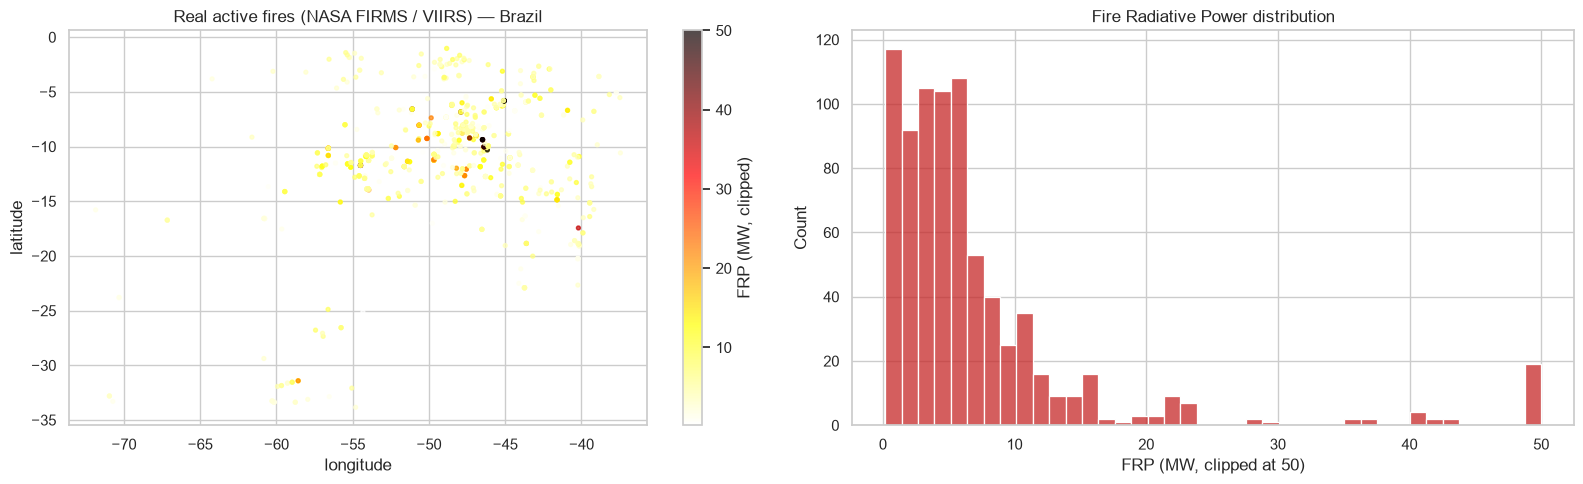

Active fire detections in window: 788
Mean FRP: 7.5 MW | Max FRP: 71.5 MW


In [13]:
if firms is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    # Geographic scatter of active fires, colored by fire radiative power.
    sc = ax1.scatter(firms["longitude"], firms["latitude"], c=firms["frp"].clip(upper=50),
                     cmap="hot_r", s=8, alpha=0.7)
    ax1.set_title("Real active fires (NASA FIRMS / VIIRS) — Brazil")
    ax1.set_xlabel("longitude")
    ax1.set_ylabel("latitude")
    plt.colorbar(sc, ax=ax1, label="FRP (MW, clipped)")
    # FRP distribution: most fires are low-intensity, few are extreme (long tail).
    sns.histplot(firms["frp"].clip(upper=50), ax=ax2, bins=40, color="#c62828")
    ax2.set_title("Fire Radiative Power distribution")
    ax2.set_xlabel("FRP (MW, clipped at 50)")
    plt.tight_layout()
    plt.show()
    print(f"Active fire detections in window: {len(firms)}")
    print(f"Mean FRP: {firms['frp'].mean():.1f} MW | Max FRP: {firms['frp'].max():.1f} MW")

> **Hybrid takeaway:** the synthetic core is validated against three independent
> real sources — UCI (fire meteorology direction), Kaggle (agronomic ranges),
> and NASA FIRMS (live satellite fires). This is the credibility layer behind
> the reproducible synthetic model the backend actually ships.

## 4. Train the RandomForest

We reuse the exact training configuration from `train.py` (single source of
truth). The model uses `class_weight="balanced"` to counter the intentional
imbalance, and we evaluate with a recall focus on the `CRITICAL` class.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    f1_score,
)

X = df[FEATURE_COLUMNS]
y = df[TARGET_COLUMN]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

target_names = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES)]
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

              precision    recall  f1-score   support

     HEALTHY      0.805     0.742     0.772       500
   ATTENTION      0.564     0.577     0.571       350
    CRITICAL      0.663     0.800     0.725       150

    accuracy                          0.693      1000
   macro avg      0.677     0.706     0.689      1000
weighted avg      0.699     0.693     0.695      1000



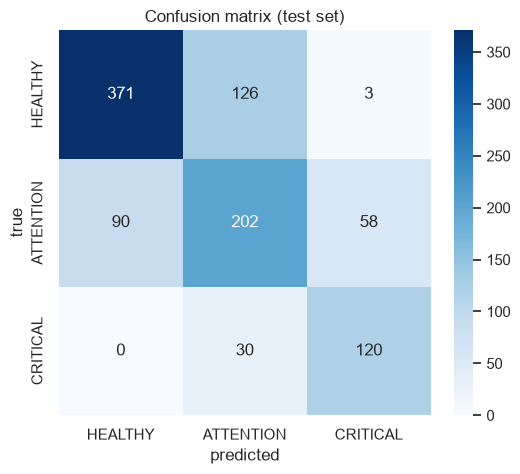

Recall (CRITICAL): 0.800
Macro F1:          0.689


In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=target_names, yticklabels=target_names,
)
plt.xlabel("predicted")
plt.ylabel("true")
plt.title("Confusion matrix (test set)")
plt.show()

rec_critical = recall_score(y_test, y_pred, labels=[2], average="macro")
macro_f1 = f1_score(y_test, y_pred, average="macro")
print(f"Recall (CRITICAL): {rec_critical:.3f}")
print(f"Macro F1:          {macro_f1:.3f}")

## 5. Model interpretability — feature importances

Importances should rank the agronomically dominant drivers first
(soil moisture and NDVI), confirming the model learned a physically
sensible mapping rather than spurious patterns.

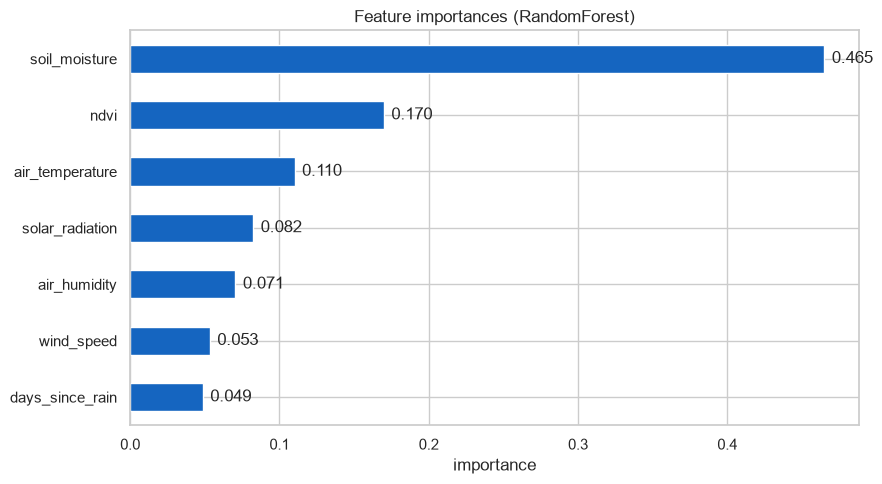

In [16]:
imp = (
    pd.Series(model.feature_importances_, index=FEATURE_COLUMNS)
    .sort_values(ascending=True)
)
ax = imp.plot(kind="barh", color="#1565c0")
ax.set_title("Feature importances (RandomForest)")
ax.set_xlabel("importance")
for i, v in enumerate(imp.values):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()

## 6. Persist the model bundle

We serialize the model **with metadata** (feature ordering + class mapping) so
the backend can load and infer without re-deriving anything. This is the same
artifact produced by `python train.py`.

In [17]:
import joblib

model_path = ML_DIR / "models" / "terra_risk.joblib"
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(
    {
        "model": model,
        "feature_columns": FEATURE_COLUMNS,
        "class_names": CLASS_NAMES,
        "version": "1.0.0",
    },
    model_path,
)
print("Saved →", model_path)

Saved → /Users/gab/Documents/CodePlay/2TIAOR-global-solution-2/ml/models/terra_risk.joblib


## 7. Quick inference sanity check

A single hand-crafted CRITICAL-looking parcel (dry soil, weak vegetation, hot,
long dry spell) should be classified as `CRITICAL`.

In [18]:
sample = pd.DataFrame([{
    "air_temperature": 39.0,
    "air_humidity": 18.0,
    "soil_moisture": 8.0,
    "solar_radiation": 950.0,
    "ndvi": 0.18,
    "days_since_rain": 30.0,
    "wind_speed": 35.0,
}])[FEATURE_COLUMNS]

pred = model.predict(sample)[0]
proba = model.predict_proba(sample)[0]
print("Predicted class:", CLASS_NAMES[pred])
print("Probabilities:", {CLASS_NAMES[i]: round(float(p), 3) for i, p in enumerate(proba)})

Predicted class: CRITICAL
Probabilities: {'HEALTHY': 0.002, 'ATTENTION': 0.048, 'CRITICAL': 0.949}


## Conclusion

- The synthetic dataset is **reproducible** (seed 42) and exhibits the intended
  class structure and physically-sensible feature relationships.
- The real **UCI Forest Fires** bridge confirms the **direction** of the key
  meteorological drivers; **Kaggle** validates the agronomic ranges; and
  **NASA FIRMS** anchors the platform in live satellite Earth-Observation data.
- The `RandomForestClassifier` achieves strong **recall on the CRITICAL class**
  (the costliest miss) with `soil_moisture` and `ndvi` as dominant drivers.
- The serialized bundle `models/terra_risk.joblib` is consumed by the backend
  `/api/predict` endpoint.

Run the CLI equivalent anytime with: `make train` (or `python train.py`).